# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [ ]:
from tensorflow.keras.datasets import fashion_mnist
#this code works because it calls the built=in function from Keras
#dataset is pre-split by Keras when you call load_data().
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
""" 
pixel values originally are from 0 to 255
we scale them from 0 to 1 ; normalize
reason: training is smoother and faster this way
"""
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Inspect the shapes of the datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [3]:
# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train_categorical = to_categorical(y_train, num_classes=10)
y_test_categorical = to_categorical(y_test, num_classes=10)

print("y_train_categorical shape:", y_train_categorical.shape)
print("y_test_categorical shape:", y_test_categorical.shape)

y_train_categorical shape: (60000, 10)
y_test_categorical shape: (10000, 10)


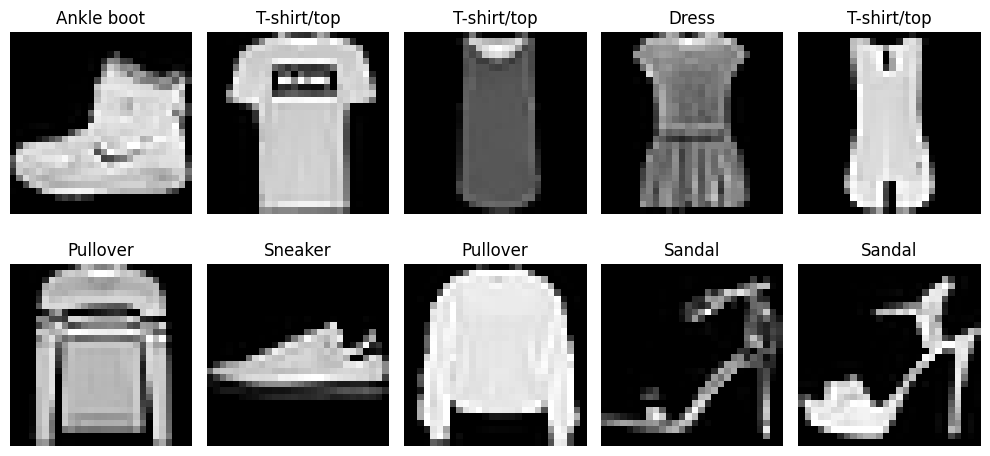

In [ ]:
# Verify the data looks as expected

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1) #creates 2X5 grid to display 10 sample images
    plt.imshow(X_train[i], cmap="gray") #display images in grayscale
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

The data looks as expected. The quality of images are high enough to decipher what the images are. Currently, there does not seem to be errors.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Evaluate the model with `model.evaluate()`

# Create a simple linear regression model
# You can use `model.add(<layer>)` to add layers to the model
""" 
Converts each 28×28 image (2D) → a vector of 784 elements (1D) -> 28*28 = 784
Needed because the Dense layer expects a 1D input.

<Dense Layer>
Single output layer with 10 neurons (one per clothing class).
softmax activation converts the outputs into probabilities summing to 1.

<Loss and Metrics>
categorical_crossentropy — appropriate for one-hot encoded labels.
accuracy — monitors how often the prediction matches the true label.

<optmizer>
adaptive learning optimizer that works well for most problems.
"""
model = Sequential()
model.add(Flatten(input_shape=(28,28))) #flatten 2D images into 1D vectors
model.add(Dense(10, activation = 'softmax')) # building a layer

# Compile the model using `model.compile()`
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # suitable for multi-class classification
    metrics=['accuracy']
)

# Train the model with `model.fit()`
history = model.fit(
    X_train, 
    y_train_categorical, 
    epochs=10, 
    batch_size=32,
    validation_split=0.2,
    verbose=2 
)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test_categorical, verbose=0)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/10


c:\Users\kyuhw\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 - 2s - 2ms/step - accuracy: 0.7866 - loss: 0.6293 - val_accuracy: 0.8292 - val_loss: 0.5096
Epoch 2/10
1500/1500 - 2s - 1ms/step - accuracy: 0.8375 - loss: 0.4743 - val_accuracy: 0.8457 - val_loss: 0.4583
Epoch 3/10
1500/1500 - 2s - 2ms/step - accuracy: 0.8485 - loss: 0.4437 - val_accuracy: 0.8516 - val_loss: 0.4370
Epoch 4/10
1500/1500 - 2s - 2ms/step - accuracy: 0.8514 - loss: 0.4295 - val_accuracy: 0.8533 - val_loss: 0.4281
Epoch 5/10
1500/1500 - 2s - 1ms/step - accuracy: 0.8554 - loss: 0.4198 - val_accuracy: 0.8368 - val_loss: 0.4584
Epoch 6/10
1500/1500 - 2s - 1ms/step - accuracy: 0.8582 - loss: 0.4106 - val_accuracy: 0.8515 - val_loss: 0.4294
Epoch 7/10
1500/1500 - 2s - 1ms/step - accuracy: 0.8598 - loss: 0.4055 - val_accuracy: 0.8516 - val_loss: 0.4258
Epoch 8/10
1500/1500 - 2s - 1ms/step - accuracy: 0.8617 - loss: 0.4016 - val_accuracy: 0.8559 - val_loss: 0.4187
Epoch 9/10
1500/1500 - 2s - 1ms/step - accuracy: 0.8613 - loss: 0.3978 - val_accuracy: 0.8503 - val_loss: 0

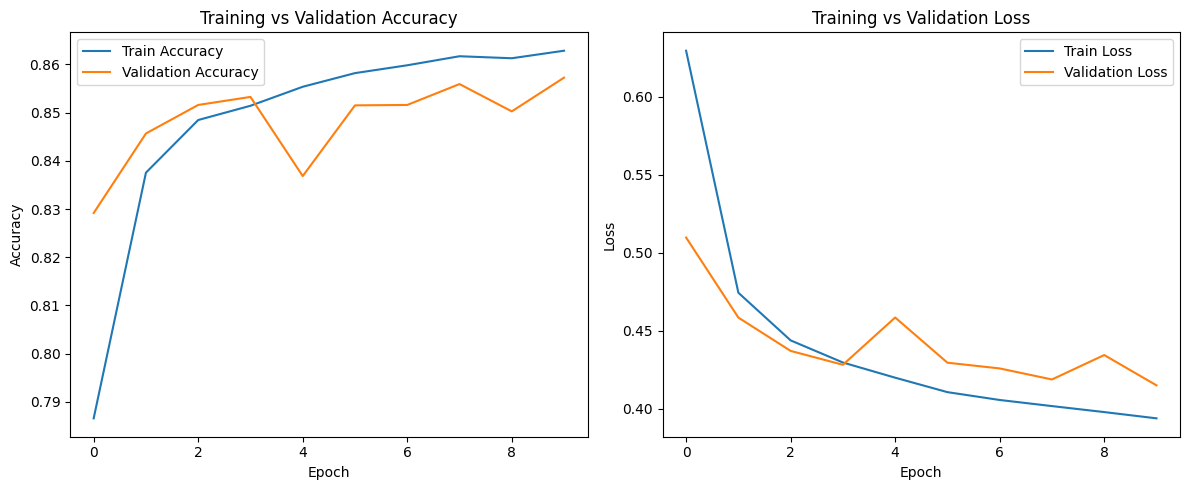

In [6]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

Performance in this case would be accuracy. After 10 epochs, Test Accuracy: 0.8455 ; Test Loss: 0.4442. Val Accuracy is steady. So far, the test output is to be expected. I believe that the test is at this level because there is only 1 Dense layer, 10 epochs and etc.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
from keras.layers import Conv2D
from keras.layers import MaxPooling2D #pools values within 4 pixels, makes it each pixel "more efficient"

""" 
convolutional neural network (CNN) is a type of deep learning algorithm designed 
to automatically analyze and interpret visual data, inspired by the human visual cortex
"""

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1) #-1, 1 are parameter 1 -> grayscale, 3 -> RGB
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN () model
model = Sequential()

#add convolutional layer, relu scales everything in positive (negative -> 0)
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

#Pooling layer (reduces spatial dimensions) , makes image smaller 
model.add(MaxPooling2D(pool_size=(2, 2)))

#Flatten to connect to fully connected layers
model.add(Flatten())

#Fully connected (dense) layer
model.add(Dense(128, activation='relu'))

#Output layer (10 classes)
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history_cnn = model.fit(
    X_train,
    y_train_categorical,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

# Evaluate the model
test_loss_cnn, test_acc_cnn = model.evaluate(X_test, y_test_categorical, verbose=0)
print(f"Test Accuracy (CNN): {test_acc_cnn:.4f}")
print(f"Test Loss (CNN): {test_loss_cnn:.4f}")

Epoch 1/10


c:\Users\kyuhw\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 - 8s - 11ms/step - accuracy: 0.8427 - loss: 0.4433 - val_accuracy: 0.8875 - val_loss: 0.3202
Epoch 2/10
750/750 - 7s - 10ms/step - accuracy: 0.8935 - loss: 0.2987 - val_accuracy: 0.8882 - val_loss: 0.3060
Epoch 3/10
750/750 - 7s - 10ms/step - accuracy: 0.9094 - loss: 0.2524 - val_accuracy: 0.8945 - val_loss: 0.2921
Epoch 4/10
750/750 - 7s - 10ms/step - accuracy: 0.9209 - loss: 0.2171 - val_accuracy: 0.9112 - val_loss: 0.2524
Epoch 5/10
750/750 - 7s - 10ms/step - accuracy: 0.9305 - loss: 0.1913 - val_accuracy: 0.9083 - val_loss: 0.2611
Epoch 6/10
750/750 - 7s - 10ms/step - accuracy: 0.9381 - loss: 0.1710 - val_accuracy: 0.9049 - val_loss: 0.2695
Epoch 7/10
750/750 - 8s - 11ms/step - accuracy: 0.9451 - loss: 0.1519 - val_accuracy: 0.9141 - val_loss: 0.2534
Epoch 8/10
750/750 - 7s - 10ms/step - accuracy: 0.9526 - loss: 0.1300 - val_accuracy: 0.9144 - val_loss: 0.2603
Epoch 9/10
750/750 - 7s - 10ms/step - accuracy: 0.9582 - loss: 0.1157 - val_accuracy: 0.9123 - val_loss: 0.2643
Epo

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

Compared to baseline where testing accuracy was ~84% , validation accuracy is ~84% and test accuracy was ~84%,
The CNN improves very significantly: testing accuracy-> ~96%, validation accuracy -> ~91%, test accuracy -> 90.9%

The CNN model outperformed the baseline by approximately 6% in test accuracy (90.9% vs 84.5%).
This improvement occurred because the CNN can learn spatial hierarchies in the image — capturing edges, textures, and shapes — while the baseline model simply treats all pixels as independent inputs.

Training accuracy: measures learning on the 80% training portion.
Validation accuracy: measures performance on the 20% validation portion (during training).
Test accuracy: measured after training on the separate 10,000 test images.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.


Training CNN with 32 filters...
Epoch 1/5


c:\Users\kyuhw\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7942 - loss: 0.5877 - val_accuracy: 0.8848 - val_loss: 0.3234
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8936 - loss: 0.3002 - val_accuracy: 0.8955 - val_loss: 0.2976
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9091 - loss: 0.2532 - val_accuracy: 0.9074 - val_loss: 0.2614
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9234 - loss: 0.2091 - val_accuracy: 0.9113 - val_loss: 0.2464
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9330 - loss: 0.1858 - val_accuracy: 0.9155 - val_loss: 0.2425
Test Accuracy with 32 filters: 0.9127

Training CNN with 64 filters...
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7920 - loss: 0.5807 - val_accuracy: 0.8844 - val_loss: 0.3187
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8940 - loss: 0.2899 - val_accuracy: 0.9013 - val_loss: 0.2736
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17

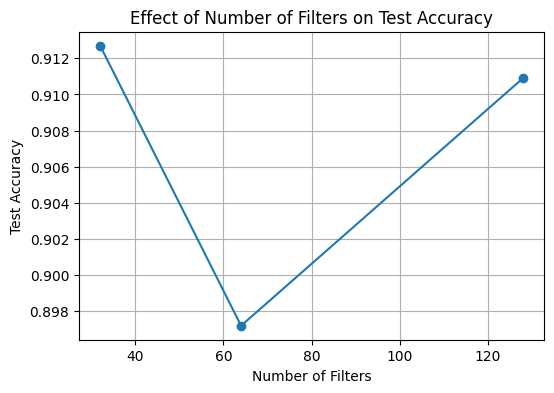

In [9]:
# A. Test Hyperparameters

#Test number of filters in the first convolutional layer as our hyperparameter
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# Store results
results = {}

# Test different numbers of filters
filter_values = [32, 64, 128]

for filters in filter_values:
    print(f"\nTraining CNN with {filters} filters...")
    
    # Rebuild model for each experiment
    model = Sequential()
    model.add(Conv2D(filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    
    # Compile
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Train
    history = model.fit(
        X_train, y_train_categorical,
        epochs=5,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )
    
    # Evaluate
    test_loss, test_acc = model.evaluate(X_test, y_test_categorical, verbose=0)
    results[filters] = test_acc
    print(f"Test Accuracy with {filters} filters: {test_acc:.4f}")

# Visualize results
plt.figure(figsize=(6, 4))
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.title("Effect of Number of Filters on Test Accuracy")
plt.xlabel("Number of Filters")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()

Conv2D layers
→ act as feature extractors
→ they use filters (kernels) to detect patterns such as edges, corners, or textures.

Dense layers
→ act as the classifier or decision maker
→ they take the features extracted by the Conv layers and decide which class the image belongs to.

In [10]:
# B. Test presence or absence of regularization (ex. drop out -> remove/pruning nodes)
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Experiment settings
use_dropout = [False, True]
results_reg = {}

for regularize in use_dropout:
    print(f"\nTraining CNN with Dropout = {regularize}")
    
    model = Sequential()
    model.add(Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)))
    model.add(MaxPooling2D((2,2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    
    if regularize:
        model.add(Dropout(0.5))  # Drop 50% of neurons during training
    
    model.add(Dense(10, activation='softmax'))
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X_train, y_train_categorical, epochs=5, batch_size=64,
                        validation_split=0.2, verbose=1)
    
    test_loss, test_acc = model.evaluate(X_test, y_test_categorical, verbose=0)
    results_reg["With Dropout" if regularize else "No Dropout"] = test_acc
    print(f"Test Accuracy: {test_acc:.4f}")

print("\nResults:", results_reg)


Training CNN with Dropout = False
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.7980 - loss: 0.5823 - val_accuracy: 0.8881 - val_loss: 0.3174
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8998 - loss: 0.2831 - val_accuracy: 0.8956 - val_loss: 0.2876
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9152 - loss: 0.2327 - val_accuracy: 0.9076 - val_loss: 0.2600
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9271 - loss: 0.1996 - val_accuracy: 0.9097 - val_loss: 0.2571
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9355 - loss: 0.1751 - val_accuracy: 0.9133 - val_loss: 0.2458
Test Accuracy: 0.9075

Training CNN with Dropout = True
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7324 - loss: 0.7614 - val_accuracy: 0.8802 - val_loss: 0.3382
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8640 - loss: 0.3850 - val_accuracy: 0.8928 - val_loss: 0.3027
Epoch 

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

The test accuracy showed a non-linear trend as the number of filters increased — high at 32, dipped at 64, and rose again at 128 filters. This suggests that while increasing filters allows the model to learn more complex features (at sacrifice for time to learn the model). However, since there were limited epochs, with more epochs, larger models very likely will outperform smaller ones

Even though raw accuracy dropped by ~1%, the validation and test losses were more stable, meaning the model generalized better.
Adding dropout (0.5) slightly reduced the test accuracy (from 0.9075 to 0.8970) but helped stabilize validation loss, indicating improved generalization.

Overall, the best performance came from the CNN with 32 filters and no dropout, which achieved the highest test accuracy (≈0.91).

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

Best hyperparameter → 32 filters (highest accuracy, simple and effective)

Best regularization → No dropout (gave slightly higher test accuracy, stable training)

In [11]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# Build the final model using best parameters
final_model = Sequential()
final_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
final_model.add(MaxPooling2D(pool_size=(2, 2)))
final_model.add(Flatten())
final_model.add(Dense(128, activation='relu'))
final_model.add(Dense(10, activation='softmax'))

# Compile the final model
final_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the final model
history_final = final_model.fit(
    X_train,
    y_train_categorical,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=2
)

# Evaluate on test data
test_loss_final, test_acc_final = final_model.evaluate(X_test, y_test_categorical, verbose=0)

print(f"Final Model Test Accuracy: {test_acc_final:.4f}")
print(f"Final Model Test Loss: {test_loss_final:.4f}")

Epoch 1/10
750/750 - 8s - 11ms/step - accuracy: 0.8497 - loss: 0.4308 - val_accuracy: 0.8848 - val_loss: 0.3264
Epoch 2/10
750/750 - 7s - 10ms/step - accuracy: 0.8959 - loss: 0.2886 - val_accuracy: 0.8942 - val_loss: 0.2956
Epoch 3/10
750/750 - 7s - 10ms/step - accuracy: 0.9106 - loss: 0.2452 - val_accuracy: 0.9055 - val_loss: 0.2614
Epoch 4/10
750/750 - 7s - 10ms/step - accuracy: 0.9221 - loss: 0.2129 - val_accuracy: 0.9084 - val_loss: 0.2566
Epoch 5/10
750/750 - 7s - 10ms/step - accuracy: 0.9309 - loss: 0.1874 - val_accuracy: 0.9096 - val_loss: 0.2586
Epoch 6/10
750/750 - 8s - 10ms/step - accuracy: 0.9398 - loss: 0.1644 - val_accuracy: 0.9068 - val_loss: 0.2685
Epoch 7/10
750/750 - 7s - 10ms/step - accuracy: 0.9466 - loss: 0.1461 - val_accuracy: 0.9112 - val_loss: 0.2631
Epoch 8/10
750/750 - 7s - 10ms/step - accuracy: 0.9525 - loss: 0.1294 - val_accuracy: 0.9153 - val_loss: 0.2616
Epoch 9/10
750/750 - 7s - 10ms/step - accuracy: 0.9579 - loss: 0.1148 - val_accuracy: 0.9157 - val_loss:

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

The final CNN model achieved a test accuracy of 90.7%: outperforming the baseline linear model by about 6%. 

This confirms that convolutional layers (CNN) significantly enhance performance on image-based tasks by capturing spatial relationships between pixels.

Compared to earlier CNN experiments, the final model maintained similar accuracy but demonstrated stable training and validation curves, showing that the chosen hyperparameters (32 filters, 128 dense units, no dropout) provided a good balance between model complexity and generalization.


If more time were available, further improvements could include:

-Adding more convolutional layers 

-Testing different kernel sizes (e.g., 5×5) to see if larger receptive fields improve accuracy.

-Increasing training epochs

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.